# Punto 4 — Visualización estadística aplicada

## *"Del gráfico que entendés vos al que entiende el otro"*

**Unidad III — Estadística Descriptiva · Diplomatura en Data Analytics (UNNE)**

> **Un gráfico hace tres trabajos distintos** y casi nadie los distingue:
>
> | | para quién | cómo es |
> |---|---|---|
> | **1 · explorar** | para vos, ahora | rápido y feo, 30 segundos |
> | **2 · decidir** | para tu equipo | comparable y honesto |
> | **3 · comunicar** | para alguien que nunca vio los datos | una sola idea, clarísima |
>
> El error más común no es elegir mal el gráfico: es **usar el de explorar para**
> **comunicar**. Un pairplot de 36 paneles es perfecto para el trabajo 1 e inservible
> para el 3.

## 0 · Setup

In [1]:
import os, sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from estadistica import clasificar_variable, graficar_relacion, comparar_segmentos

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/housing.csv")
df["ambientes_por_hogar"] = df["total_rooms"] / df["households"]
GRUPO, VALOR = "ocean_proximity", "median_house_value"
print(f"{df.shape[0]:,} filas × {df.shape[1]} columnas")

20,640 filas × 11 columnas


## 1 · El gráfico no se elige: se deduce

La pregunta no es *"¿qué gráfico me gusta?"* sino **¿cuántas variables tengo, y de
qué tipo es cada una?**. Con esas dos respuestas el gráfico queda determinado.

| Qué tengo | Qué pregunto | Gráfico |
|---|---|---|
| 1 numérica | ¿qué forma tiene? | histograma |
| 1 categórica | ¿cómo se reparte? | barras |
| num × num | ¿se relacionan? | scatter |
| cat × num | ¿difieren los grupos? | boxplot |
| cat × cat | ¿se reparten igual? | barras apiladas |
| muchas numéricas | ¿por dónde empiezo? | heatmap |

**Esta es la tabla a la que vas a volver durante el TP.**

Y el tipo de variable ya lo sabemos calcular: `clasificar_variable()`, la función que
escribimos en vivo en la sincrónica 1. Así que la elección se puede automatizar.

In [2]:
for col in [GRUPO, VALOR, "median_income", "housing_median_age"]:
    print(f"  {col:<20} → {clasificar_variable(df[col])}")

  ocean_proximity      → cualitativa (nominal)
  median_house_value   → cuantitativa continua
  median_income        → cuantitativa continua
  housing_median_age   → cuantitativa continua


### 1.1 · `graficar_relacion()` decide sola

Acá el sistema **se usa a sí mismo**: para decidir qué dibujar, llama a la función
que escribieron ustedes hace dos clases.

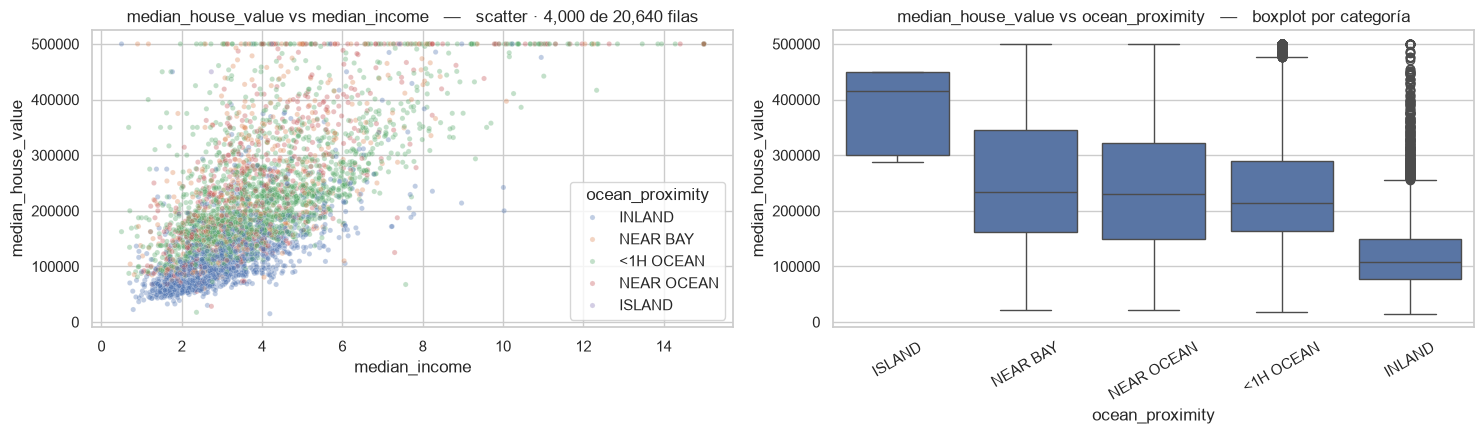

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# num × num  → elige scatter
graficar_relacion(df, "median_income", VALOR, columna_color=GRUPO, ax=axes[0])

# cat × num  → elige boxplot
graficar_relacion(df, GRUPO, VALOR, ax=axes[1])

plt.tight_layout(); plt.show()

#### ⚠️ Forzando el concepto (1): la torta que borra a `ISLAND`

In [4]:
reparto = df[GRUPO].value_counts()
print(pd.DataFrame({"n": reparto,
                    "% del total": (reparto / len(df) * 100).round(3)}).to_string())

print(f"\nISLAND ocupa {5/len(df)*360:.2f} grados de una circunferencia.")

                    n  % del total
ocean_proximity                   
<1H OCEAN        9136       44.264
INLAND           6551       31.739
NEAR OCEAN       2658       12.878
NEAR BAY         2290       11.095
ISLAND              5        0.024

ISLAND ocupa 0.09 grados de una circunferencia.


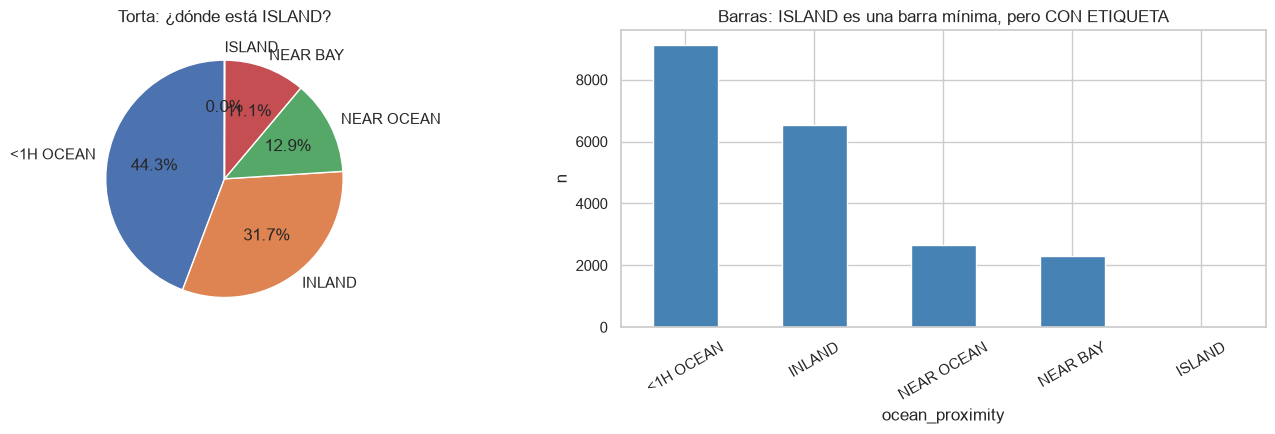

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.pie(reparto, labels=reparto.index, autopct="%1.1f%%", startangle=90)
ax1.set_title("Torta: ¿dónde está ISLAND?")

reparto.plot(kind="bar", ax=ax2, color="steelblue")
ax2.set_title("Barras: ISLAND es una barra mínima, pero CON ETIQUETA")
ax2.set_ylabel("n"); ax2.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

> **`ISLAND` no queda chiquito en la torta: queda literalmente invisible.** 0,09
> grados es menos que el ancho de la línea del borde. Y es el grupo del que venimos
> hablando hace tres clases.
>
> El punto no es *"las tortas son malas"*. Es que **cada gráfico decide qué se puede
> ver**, y la torta decide no mostrar lo chico. A veces está bien. Acá lo chico es
> justo lo interesante.

#### ⚠️ Forzando el concepto (2): el eje que cambia la conclusión

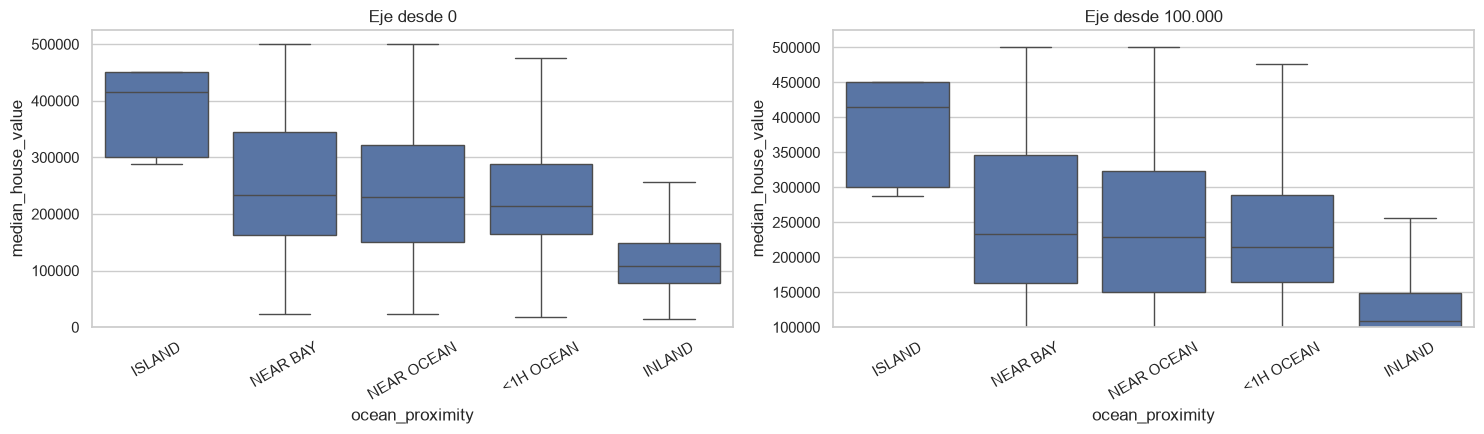

Mismos datos. Misma función. Cambia dónde arranca el eje y.


In [6]:
orden = df.groupby(GRUPO)[VALOR].median().sort_values(ascending=False).index
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5), sharey=False)

for ax, limite, titulo in [
    (ax1, (0, None),       "Eje desde 0"),
    (ax2, (100_000, None), "Eje desde 100.000"),
]:
    sns.boxplot(data=df, x=GRUPO, y=VALOR, order=orden, ax=ax, showfliers=False)
    ax.set_ylim(limite)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()
print("Mismos datos. Misma función. Cambia dónde arranca el eje y.")

> **El eje no es un detalle técnico: es un argumento.** Las dos versiones son
> técnicamente correctas y sugieren conclusiones distintas sobre cuán separados están
> los grupos.
>
> No está prohibido truncar el eje —a veces es lo correcto—. Está prohibido
> **truncarlo en silencio**. Si lo hacés, que se lea en el gráfico.

## 2 · Seaborn: cuatro funciones cubren casi todo

| función | para qué |
|---|---|
| `sns.histplot` | una numérica: la forma |
| `sns.boxplot` | una categórica y una numérica: comparar grupos |
| `sns.scatterplot` | dos numéricas: la relación |
| `sns.heatmap` | una matriz: por dónde empezar |

No hace falta más para todo el TP.

### 2.1 · `hue`: una tercera variable sin un tercer eje

Dos ejes son dos variables. El **color** agrega una tercera sin salir del plano.

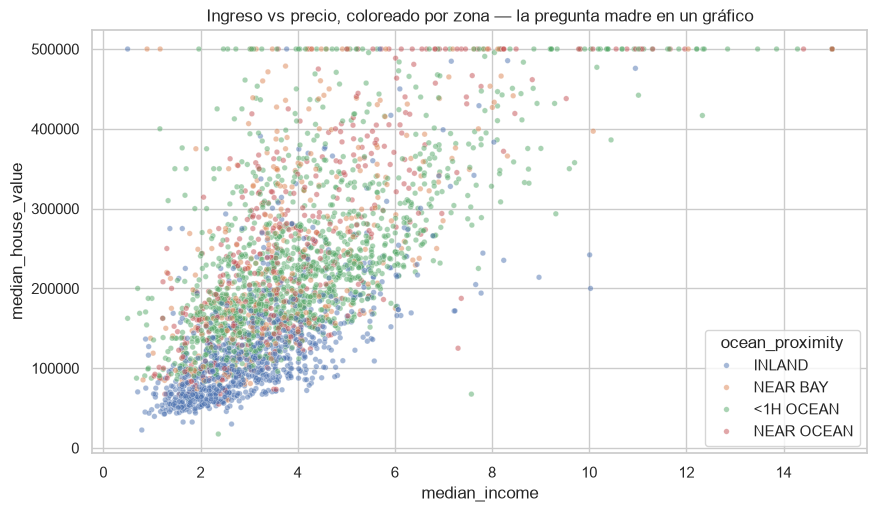

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.scatterplot(data=df.sample(3000, random_state=42),
                x="median_income", y=VALOR, hue=GRUPO,
                alpha=0.5, s=16, ax=ax)
ax.set_title("Ingreso vs precio, coloreado por zona — la pregunta madre en un gráfico")
plt.show()

> Si tuvieras que mostrar **un solo gráfico** de toda la unidad, es este: se ve la
> relación ingreso-precio, se ven los segmentos separados, y se ve la línea horizontal
> del tope de 500.001 cortando todo por arriba.

#### ⚠️ Forzando el concepto: 20.640 puntos son una mancha

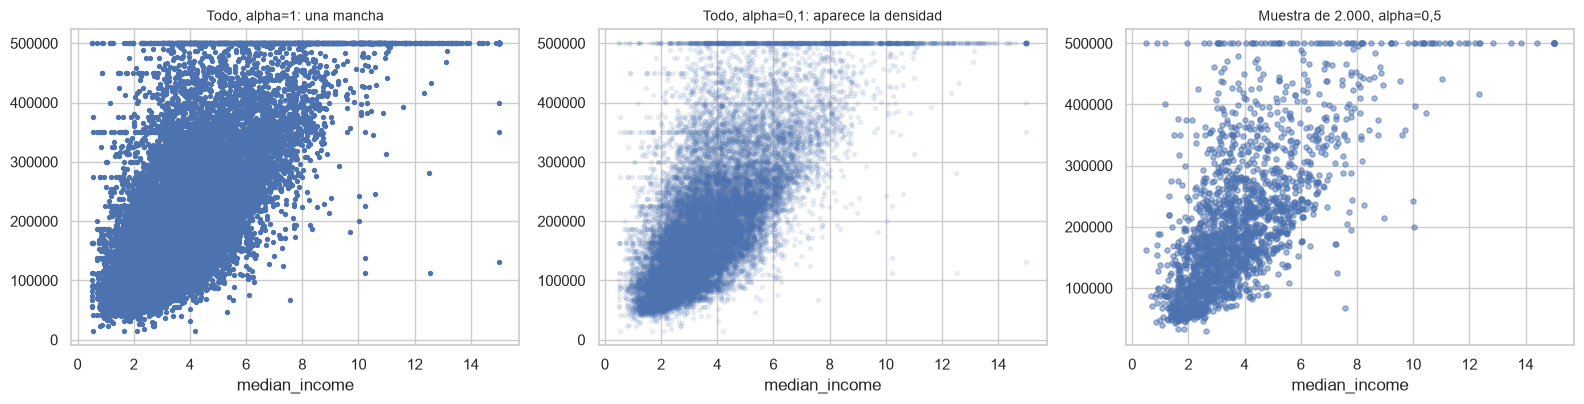

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

config = [
    (df,                              1.0, 8,  "Todo, alpha=1: una mancha"),
    (df,                              0.1, 8,  "Todo, alpha=0,1: aparece la densidad"),
    (df.sample(2000, random_state=42), 0.5, 14, "Muestra de 2.000, alpha=0,5"),
]
for ax, (datos, a, s, titulo) in zip(axes, config):
    ax.scatter(datos["median_income"], datos[VALOR], alpha=a, s=s)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("median_income")

plt.tight_layout(); plt.show()

> **El primer gráfico está técnicamente bien hecho y no sirve para nada.** El problema
> no es el código: es la cantidad de tinta por dato.
>
> Con `alpha` bajo, donde hay muchos puntos encimados el color se satura — y eso
> **vuelve a ser información**: el gráfico pasa a mostrar densidad además de posición.
>
> **`alpha` y `sample` no son cosmética: cambian lo que se puede concluir.** Y el
> `random_state` va fijo, para que el gráfico no cambie en cada corrida. (La misma
> precaución que vamos a necesitar en el punto 5, con el bootstrap.)

## 3 · Cómo se escribe un hallazgo

Tres líneas. Siempre las mismas tres.

| | qué va |
|---|---|
| **1 · qué se ve** | el patrón, en lenguaje de persona |
| **2 · cuánto es** | el número que lo respalda, **con su `n`** |
| **3 · qué no puedo afirmar** | el límite: lo que este dato todavía no autoriza a decir |

Vamos a escribir el mismo hallazgo tres veces, mejorándolo.

In [9]:
tabla = comparar_segmentos(df, GRUPO, VALOR, graficar=False)
print(tabla[["n", "media", "mediana", "cv", "% del total"]].round(2).to_string())

                      n      media   mediana    cv  % del total
ocean_proximity                                                
ISLAND              5.0  380440.00  414700.0  0.21          0.0
NEAR BAY         2290.0  259212.31  233800.0  0.47         11.1
NEAR OCEAN       2658.0  249433.98  229450.0  0.49         12.9
<1H OCEAN        9136.0  240084.29  214850.0  0.44         44.3
INLAND           6551.0  124805.39  108500.0  0.56         31.7


### Versión 1

> *"Los barrios costeros son más caros que los del interior."*

Es verdad, se entiende y no dice nada falso. **Y sin embargo no sirve:** ¿cuánto más
caros? ¿comparado con qué? ¿sobre cuántos casos?

No es un error: es **incompleto**. La diferencia importa, porque a quien escribe esto
no le falta conocimiento, le falta el hábito.

In [10]:
# Los dos números que le faltan a la versión 1:
costa = df[df[GRUPO] == "<1H OCEAN"][VALOR]
interior = df[df[GRUPO] == "INLAND"][VALOR]
print(f"<1H OCEAN  mediana = {costa.median():>9,.0f}   n = {len(costa):,}")
print(f"INLAND     mediana = {interior.median():>9,.0f}   n = {len(interior):,}")
print(f"razón = {costa.median() / interior.median():.2f}×")

<1H OCEAN  mediana =   214,850   n = 9,136
INLAND     mediana =   108,500   n = 6,551
razón = 1.98×


### Versión 2 — con el número y el `n`

> *"La mediana de precio de los barrios a menos de una hora del mar es 214.850 USD,
> contra 108.500 en los del interior: casi el doble (n = 9.136 y 6.551)."*

Mucho mejor: es verificable, tiene magnitud y tiene `n`.

Fijate en dos decisiones de redacción: usamos **mediana** y no media (por lo del punto
2), y escribimos **"casi el doble"** en vez de "1,98 veces". Se escribe para el que
lee, no para el que calculó.

**Pero todavía le falta la tercera línea.**

In [11]:
# Las dos razones concretas para dudar, que salen del punto 3:
print("1. ¿Puede haber una tercera variable?")
ing = df.groupby(GRUPO)["median_income"].median().round(2)
print(ing.sort_values(ascending=False).to_string())

print("\n2. ¿El problema de calidad afecta parejo a los grupos?")
topeadas = (df[df[VALOR] >= 500_001].groupby(GRUPO).size().reindex(df[GRUPO].unique(), fill_value=0)
            / df.groupby(GRUPO).size() * 100)
print(topeadas.round(2).sort_values(ascending=False).to_string())

1. ¿Puede haber una tercera variable?
ocean_proximity
<1H OCEAN     3.88
NEAR BAY      3.82
NEAR OCEAN    3.65
INLAND        2.99
ISLAND        2.74

2. ¿El problema de calidad afecta parejo a los grupos?
ocean_proximity
NEAR BAY      8.47
NEAR OCEAN    7.98
<1H OCEAN     5.82
INLAND        0.41
ISLAND        0.00


### Versión 3 — la tercera línea

> *"La mediana de precio de los barrios a menos de una hora del mar es 214.850 USD,
> contra 108.500 en los del interior: casi el doble (n = 9.136 y 6.551).*
> *No podemos afirmar que la cercanía al mar sea la causa: los barrios costeros
> también tienen ingresos medianos más altos, y el tope de 500.001 los afecta unas 14
> veces más que al interior, con lo cual la diferencia real podría ser todavía mayor."*

> **Esa línea no debilita el hallazgo: lo hace confiable.** Y no salió de la nada —
> son exactamente las dos trampas del punto 3: **una posible variable de confusión** y
> **un problema de calidad que sesga la comparación**.
>
> **El punto 4 no agrega contenido nuevo: le da forma de texto al punto 3.**

## 4 · Lo que hay que llevarse del punto 4

1. **El gráfico se deduce del tipo de variable**, no del gusto.
2. **Explorar y comunicar** son dos trabajos con dos gráficos distintos.
3. **Ningún gráfico es neutral**: cada uno decide qué se puede ver.
4. **Truncar el eje no está prohibido; truncarlo en silencio sí.**
5. **`hue`** mete una tercera variable sin un tercer eje.
6. Con muchos puntos, **`alpha` y `sample` son análisis**, no cosmética.
7. **Un hallazgo son tres líneas**, y la tercera es la que cuesta.